# Setup

```from packaging import version```

This project requires:
- Python 3.7 or above
- Scikit-Learn ≥ 1.0.1
- TensorFlow ≥ 2.8

```
import sys

assert sys.version_info >= (3, 7)
```

then:

```
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
```

then:

```
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")
```

In [1]:
import sklearn
import tensorflow as tf
import sys

print("scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)

scikit-learn version: 1.6.1
TensorFlow version: 2.18.0


Let's define the default font sizes to make the figures prettier:

In [2]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This project can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [3]:
# Detect environment
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')

if not gpus:
    print("❌ No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("➡️ Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    elif IS_KAGGLE:
        print("➡️ Go to Settings > Accelerator and select GPU.")
    elif IS_LOCAL:
        print("➡️ You are running locally. Make sure:")
        print("  1. You have installed the GPU version of TensorFlow (e.g. `pip install tensorflow` or `pip install tensorflow-gpu` for older versions).")
        print("  2. You have a compatible NVIDIA driver and CUDA/cuDNN toolkit.")
else:
    print("✅ GPU detected:", gpus)

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


```
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
```

`!where python`

`!nvidia-smi`

[TensorFlow-GPU compatibility table](https://www.tensorflow.org/install/source#gpu)

Check here to handle dependencies for GPU support by your TensorFlow.

# Convolutional Layers

The most important building block of a CNN is the **convolutional layer**: neurons in the ***first convolutional layer*** are not connected to every single pixel in the ***input image*** (like they are in the layers of an FFNN), but only to pixels in their receptive fields (see Figure below). In turn, each neuron in the ***second convolutional layer*** is connected only to neurons located within a *small rectangle* in the first layer. This architecture allows the network to **concentrate on small low-level features** in the first hidden layer, then **assemble them into larger higher-level features** in the next hidden layer, and so on. This hierarchical structure is common in real-world images, which is one of the reasons why CNNs work so well for image recognition.

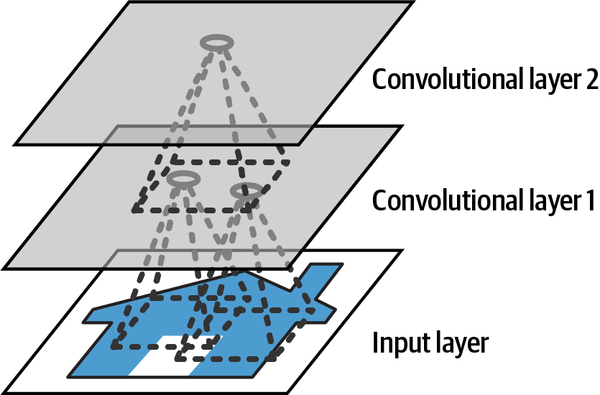

## Theory

A neuron located in row *i*, column *j* of a given layer is connected to the outputs of the neurons in the previous layer located in rows *i* to *i + fh – 1*, columns *j* to *j + fw – 1*, where *fh* and *fw* are the ***height and width of the receptive field*** (see Figure below). In order for a layer to have the same height and width as the previous layer, it is common to add zeros around the inputs, as shown in the diagram. This is called ***zero padding***.

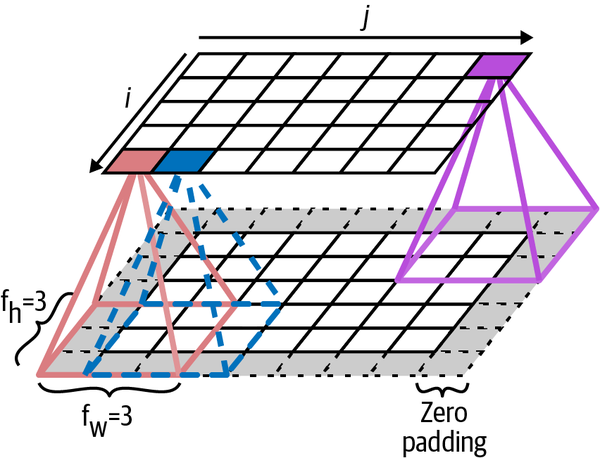

It is also possible to connect a large input layer to a much smaller layer by *spacing out the receptive fields*, as shown in Figure below. This dramatically *reduces the model’s computational complexity*. ```The horizontal or vertical step size from one receptive field to the next``` is called the **stride**. In the diagram, a 5 × 7 input layer (plus zero padding) is connected to a 3 × 4 layer, using 3 × 3 receptive fields and a stride of 2 (in this example the stride is the same in both directions, but it does not have to be so). A neuron located in row *i*, column *j* in the upper layer is connected to the outputs of the neurons in the previous layer located in rows *i × sh* to *i × sh + fh – 1*, columns *j × sw* to *j × sw + fw – 1*, where ***sh*** and ***sw*** are the ***vertical and horizontal strides***.

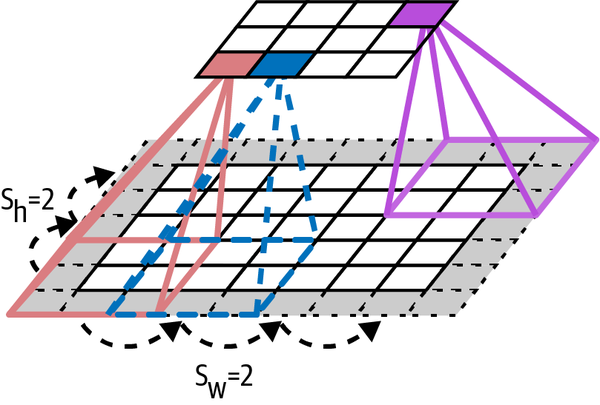

**Filters**

A neuron’s weights can be represented as a small image the size of the receptive field. For example, Figure below shows two possible sets of weights, called ***filters*** (or ***convolution kernels***, or just ***kernels***). The first one is represented as a black square with a vertical white line in the middle (***it’s a 7 × 7 matrix full of 0s except for the central column, which is full of 1s***); neurons using these weights will *ignore everything in their receptive field except for the central vertical line* (since ***all inputs will be multiplied by 0, except for the ones in the central vertical line***). The second filter is a black square with a horizontal white line in the middle. Neurons using these weights will *ignore everything in their receptive field except for the central horizontal line*.

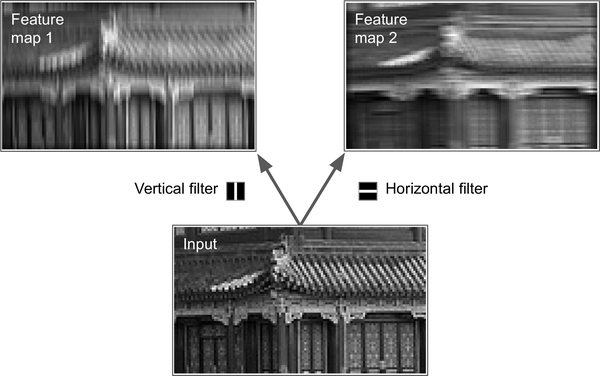

Based on this description, we're referring to two classic convolution filters:

---

## 1. **Vertical Filter (7×7)**

A filter with **1s in the central column**, 0s elsewhere:

```python
import numpy as np

vertical_filter = np.array([
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
])
```

---

## 2. **Horizontal Filter (7×7)**

A filter with **1s in the central row**, 0s elsewhere:

```python
horizontal_filter = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])
```

---

These are simple **edge-detection filters**:

* The **vertical filter** will highlight **vertical edges/structures**.
* The **horizontal filter** will highlight **horizontal edges/structures**.

---

Now if all neurons in a layer use the same vertical line filter (and the same bias term), and you feed the network the input image shown in Figure above (the bottom image), the layer will output the top-left image. Notice that the vertical white lines get enhanced while the rest gets blurred. Similarly, the upper-right image is what you get if all neurons use the same horizontal line filter; notice that the horizontal white lines get enhanced while the rest is blurred out. Thus, a layer full of neurons using the same filter outputs a ***feature map***, which *highlights the areas in an image that activate the filter the most*. But *we won’t have to define the filters manually*: instead, ***during training the convolutional layer will automatically learn the most useful filters for its task***, and the ***layers*** above ***will learn to combine them into more complex patterns***.

**Stacking Multiple Feature Maps**

In a convolutional neural network (CNN), each convolutional layer applies **multiple filters** to the input. Each filter detects a specific type of pattern (like edges, textures, etc.) and produces its own **feature map**. So instead of a 2D layer, each convolutional layer outputs a **3D stack** of feature maps.

Each filter looks at small regions of the input but across **all channels** (e.g., R, G, B in a color image). All the neurons in one feature map **share the same filter**, which reduces the number of parameters and makes the model efficient.

This shared filtering also means that if the model learns a pattern in one part of the image, it can recognize that same pattern **anywhere** in the image — unlike fully connected layers, which learn fixed-position patterns.

In short:

* Input = multi-channel (e.g., RGB)
* Filters = slide over the input, each creating a feature map
* Output = stack of 2D feature maps = 3D data
* Efficient and good at detecting patterns **regardless of position**.
---

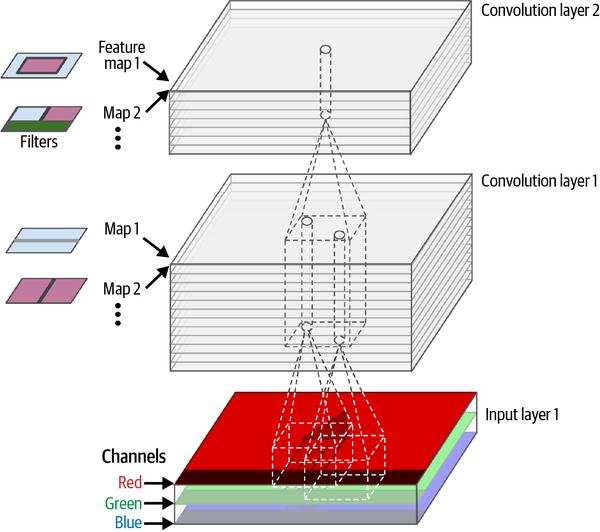

Based on the illustration above, here’s a concrete **mathematical example** that aligns with the figure:

---

### **Input Layer (Image):**

* Shape:

  $$
  \text{Input shape} = (H, W, C_{\text{in}}) = (32, 32, 3)
  $$

  This corresponds to a **color image** with 3 channels (Red, Green, Blue).

---

### **Convolution Layer 1:**

* Suppose we use **8 filters**, each of size $3 \times 3 \times 3$ (height × width × input channels).
* Each filter scans across the RGB channels of the input.
* Output:

  $$
  \text{Output shape} = (32, 32, 8)
  $$

  → 8 **feature maps**, one from each filter.

---

### **Convolution Layer 2:**

* Now apply **16 filters**, each of size $3 \times 3 \times 8$, to the output from Layer 1.
* Each filter scans across all **8 feature maps** from the previous layer.
* Output:

  $$
  \text{Output shape} = (32, 32, 16)
  $$

  → 16 new feature maps stacked together.

---

### **Summary Flow (shape progression):**

$$
(32, 32, 3) \xrightarrow{\text{Conv1: 8 filters}} (32, 32, 8) \xrightarrow{\text{Conv2: 16 filters}} (32, 32, 16)
$$

Each filter connects across **all channels** of the previous layer, and every convolutional layer **adds depth** by stacking more feature maps.

## Implementing Convolutional Layers With Keras

Let's load 2 sample images, rescale their pixel values to 0-1, and center crop them to small 70×120 images:

In [4]:
from sklearn.datasets import load_sample_images
import tensorflow as tf

images = load_sample_images()["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

In [5]:
images.shape

TensorShape([2, 70, 120, 3])

In [6]:
tf.random.set_seed(42)  # ensures reproducibility
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7)
fmaps = conv_layer(images)

In [7]:
fmaps.shape

TensorShape([2, 64, 114, 32])

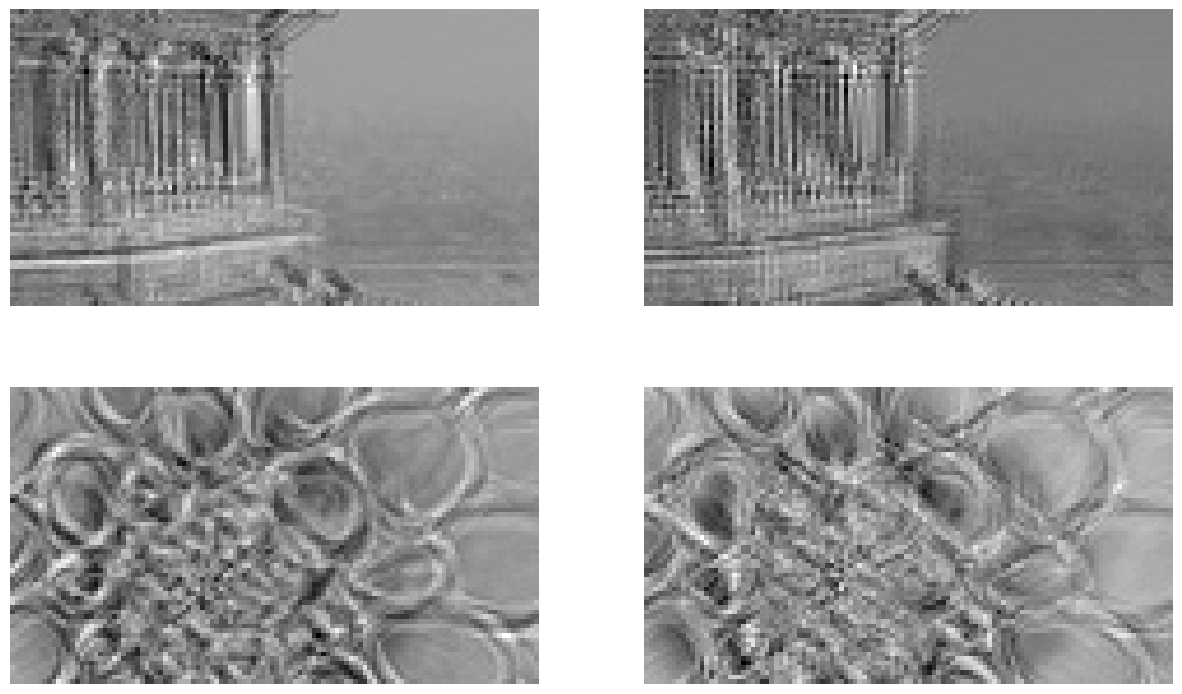

In [8]:
# display the 2 output feature maps for each image

plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

As we can see, randomly generated filters typically act like edge detectors, which is great since that's a useful tool in image processing, and that's the type of filters that a convolutional layer typically starts with. Then, during training, it gradually learns improved filters to recognize useful patterns for the task.

Now let's use zero-padding:

In [9]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same")
fmaps = conv_layer(images)

In [10]:
fmaps.shape

TensorShape([2, 70, 120, 32])

In [11]:
# shows that the output shape when we set strides=2
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 35, 60, 32])

In [12]:
# this utility function can be useful to compute the size of the
#              feature maps output by a convolutional layer. It also returns
#              the number of ignored rows or columns if padding="valid", or the
#              number of zero-padded rows or columns if padding="same"."""

import numpy as np

def conv_output_size(input_size, kernel_size, strides=1, padding="valid"):
    if padding=="valid":
        z = input_size - kernel_size + strides
        output_size = z // strides
        num_ignored = z % strides
        return output_size, num_ignored
    else:
        output_size = (input_size - 1) // strides + 1
        num_padded = (output_size - 1) * strides + kernel_size - input_size
        return output_size, num_padded

conv_output_size(np.array([70, 120]), kernel_size=7, strides=2, padding="same")

(array([35, 60]), array([5, 5]))

Let's now look at the weights:

In [13]:
kernels, biases = conv_layer.get_weights()
kernels.shape

(7, 7, 3, 32)

In [14]:
biases.shape

(32,)

In [15]:
# shows how to use the tf.nn.conv2d() operation

tf.random.set_seed(42)
filters = tf.random.normal([7, 7, 3, 2])
biases = tf.zeros([2])
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

Let's manually create 2 filters full of 0s, except for a vertical line of 1s in the first filter, and a horizontal one in the second filter. The 2 output feature maps highlight vertical lines and horizontal lines, respectively. In practice we will probably never need to create filters manually, since the convolutional layers will learn them automatically.

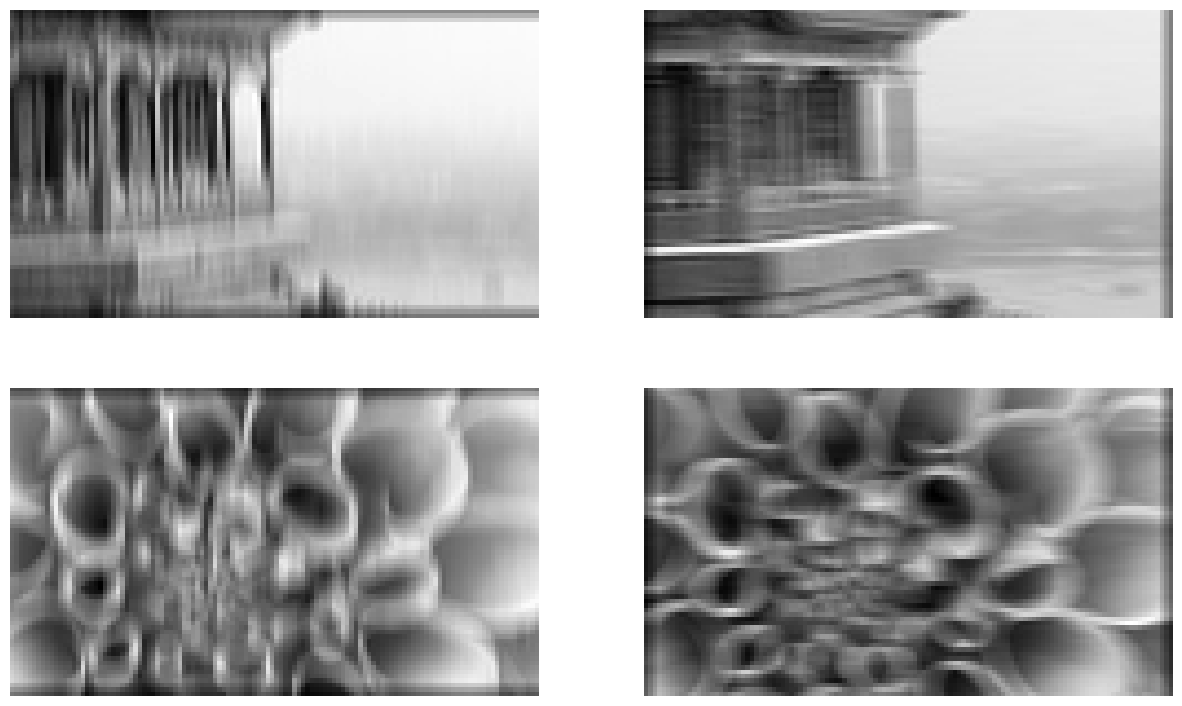

In [16]:
# shows how to manually create two filters.

plt.figure(figsize=(15, 9))
filters = np.zeros([7, 7, 3, 2])
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

Notice the **dark lines** at the *top and bottom* of the 2 images *on the left*, and on the *left and right* of the 2 images *on the right*?

These are artifacts due to the fact that we used **zero padding** in this case, while we did not use zero padding to create the feature maps in the previous figure. Because of zero padding, the 2 feature maps based on the vertical line filter (i.e., the 2 left images) ***could not fully activate near the top and bottom of the images***. Similarly, the 2 feature maps based on the horizontal line filter (i.e., the 2 right images) ***could not fully activate near the left and right of the images***.

# Pooling Layers

Their goal is to **subsample** (i.e., shrink) the input image in order to reduce the computational load, the memory usage, and the number of parameters (thereby limiting the risk of overfitting).

Just like in convolutional layers, each neuron in a pooling layer is connected to the outputs of a limited number of neurons in the previous layer, located within a small rectangular receptive field. You must define its size, the stride, and the padding type, just like before. However, a *pooling neuron has no weights*; all it does is ***aggregate*** the inputs using an aggregation function such as the max or mean. Figure below shows a ***max pooling layer***, which is the most common type of pooling layer. In this example, we use a 2 × 2 *pooling kernel*, with a stride of 2 and no padding. Only the max input value in each receptive field makes it to the next layer, while the other inputs are dropped. For example, in the lower-left receptive field in Figure below, the input values are 1, 5, 3, 2, so *only the max value, 5, is propagated to the next layer*. Because of the stride of 2, the output image has half the height and half the width of the input image (rounded down since we use no padding).

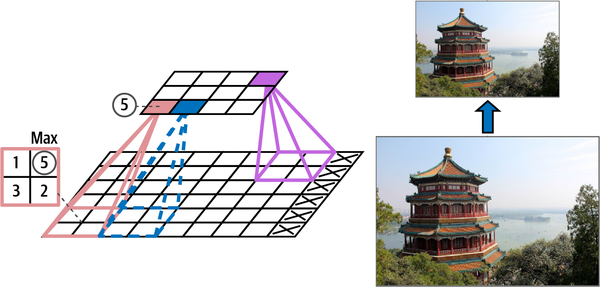

**Note**: A pooling layer typically works on every input channel independently, so the output depth (i.e., the number of channels) is the same as the input depth.

---

Other than reducing computations, memory usage, and the number of parameters, a max pooling layer also introduces some level of ***invariance*** to small translations, as shown in Figure below. Here we assume that the bright pixels have a lower value than dark pixels, and we consider three images (A, B, C) going through a max pooling layer with a 2 × 2 kernel and stride 2. Images B and C are the same as image A, but shifted by one and two pixels to the right. As you can see, ***the outputs of the max pooling layer for images A and B are identical. This is what translation invariance means.*** For image C, the output is different: it is shifted one pixel to the right (***but there is still 50% invariance***). By inserting a max pooling layer every few layers in a CNN, it is possible to get some level of translation invariance at a larger scale. Moreover, max pooling offers a small amount of ***rotational invariance*** and a slight ***scale invariance***. Such invariance (even if it is limited) can be ***useful*** in cases where the prediction should not depend on these details, such as in ***classification tasks***.

However, max pooling has some ***downsides*** too. It’s obviously very destructive: even with a tiny 2 × 2 kernel and a stride of 2, the ***output will be 2 times smaller in both directions*** (so its area will be four times smaller), ***simply dropping 75% of the input values***. And in some applications, ***invariance is not desirable***. Take ***semantic segmentation*** (the task of classifying each pixel in an image according to the object that pixel belongs to): obviously, if the input image is translated by one pixel to the right, the output should also be translated by one pixel to the right. The goal in this case is ***equivariance***, not invariance: ***a small change to the inputs should lead to a corresponding small change in the output***.

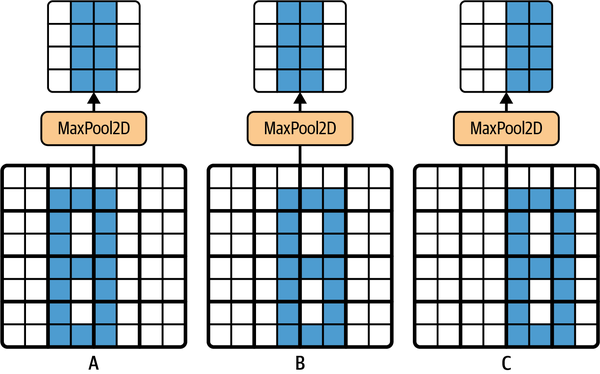

## Implementing Pooling Layers With Keras

### Max pooling

In [17]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)

In [18]:
output = max_pool(images)

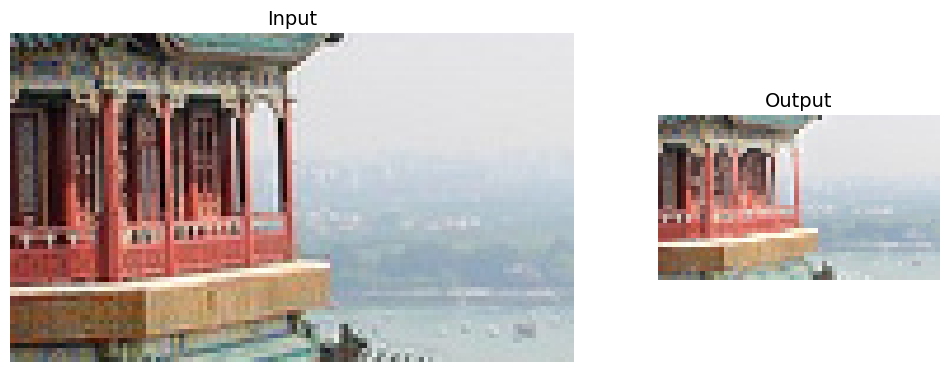

In [19]:
# this cells shows what max pooling with stride = 2 looks like

import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input")
ax1.imshow(images[0])  # plot the 1st image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output")
ax2.imshow(output[0])  # plot the output for the 1st image
ax2.axis("off")
plt.show()

### Depth-wise pooling

In [20]:
# shows how to use the max_pool() op; only works on the CPU
np.random.seed(42)
fmaps = np.random.rand(2, 70, 120, 60)
with tf.device("/cpu:0"):
    output = tf.nn.max_pool(fmaps, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding="VALID")
output.shape

TensorShape([2, 70, 120, 20])

In [21]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        shape = tf.shape(inputs)  # shape[-1] is the number of channels
        groups = shape[-1] // self.pool_size  # number of channel groups
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

In [22]:
# shows that this custom layer gives the same result as max_pool()
np.allclose(DepthPool(pool_size=3)(fmaps), output)

True

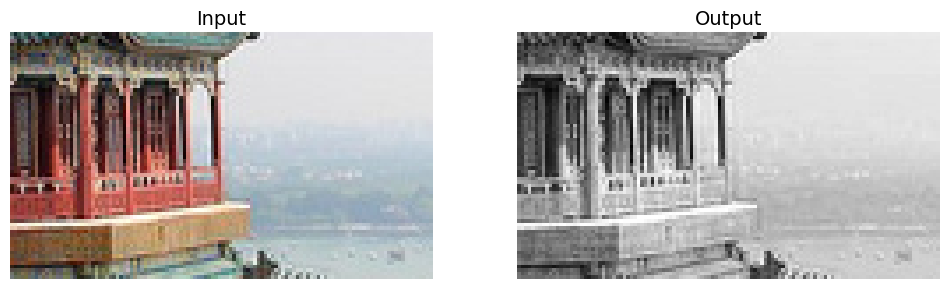

In [23]:
# computes and displays the output of the depthwise pooling layer

depth_output = DepthPool(pool_size=3)(images)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(images[0])  # plot the 1st image
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Output")
plt.imshow(depth_output[0, ..., 0], cmap="gray")  # plot 1st image's output
plt.axis("off")
plt.show()

### Global Average Pooling

In [27]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

The following layer is equivalent:

In [28]:
global_avg_pool = tf.keras.layers.Lambda(
    lambda X: tf.reduce_mean(X, axis=[1, 2])
)

In [29]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

# CNN Architectures



### Tackling Fashion MNIST With a CNN

In [30]:
# loads the mnist dataset, add the channels axis to the inputs, scales the values to the 0-1 range, and splits the dataset
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
from functools import partial

tf.random.set_seed(42)  # ensures reproducibility
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# compiles, fits, evaluates, and uses the model to make predictions
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.6099 - loss: 1.0888 - val_accuracy: 0.8636 - val_loss: 0.3760
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.8517 - loss: 0.4399 - val_accuracy: 0.8818 - val_loss: 0.3087
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8812 - loss: 0.3570 - val_accuracy: 0.8852 - val_loss: 0.2958
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8930 - loss: 0.3151 - val_accuracy: 0.9028 - val_loss: 0.2730
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9042 - loss: 0.2864 - val_accuracy: 0.9018 - val_loss: 0.2886
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9104 - loss: 0.2630 - val_accuracy: 0.9056 - val_loss: 0.2694
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9168 - loss: 0.2396 - val_accuracy: 0.9038 - val_loss: 0.2701
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9213 - loss: 

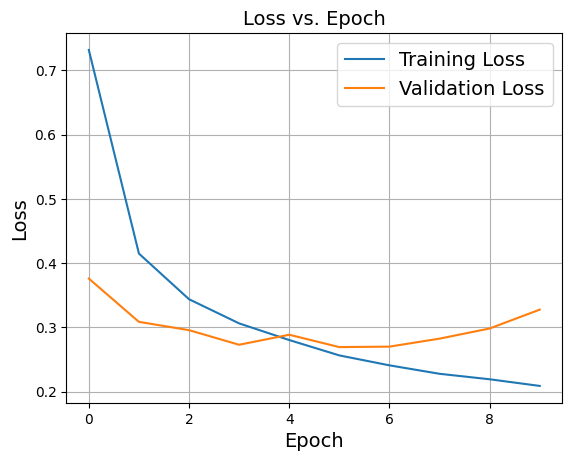

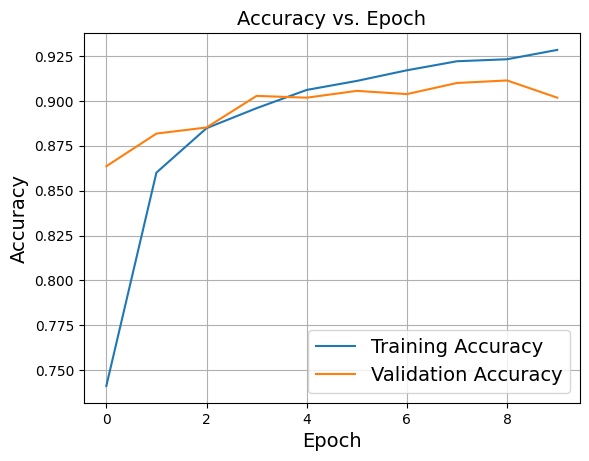

In [33]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Implementing a ResNet-34 CNN Using Keras

In [34]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [35]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Using Pretrained Models from Keras

In [36]:
model = tf.keras.applications.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Warning**: The expression `load_sample_images()["images"]` returns a Python list of images. However, in the latest versions, Keras does not accept Python lists anymore, so we must convert this list to a tensor. We can do this using `tf.constant()`, but here the `K.constant()` is used instead: it simply calls `tf.constant()` if you are using TensorFlow as the backend (as is the case here), but if you ever decide to use JAX or PyTorch as the backend instead, `K.constant()` will call the appropriate function from the chosen backend.

In [37]:
K = tf.keras.backend
images = K.constant(load_sample_images()["images"])
images_resized = tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True)(images)

In [38]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

In [39]:
Y_proba = model.predict(inputs)
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


(2, 1000)

In [40]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image #0
  n03877845 - palace       54.69%
  n03781244 - monastery    24.71%
  n02825657 - bell_cote    18.55%
Image #1
  n04522168 - vase         32.67%
  n11939491 - daisy        17.82%
  n03530642 - honeycomb    12.04%


In [ ]:
# displays the cropped and resized images

plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()

# Pretrained Models for Transfer Learning

If you want to build an image classifier but you do not have enough data to train it from scratch, then it is often a good idea to reuse the lower layers of a pretrained model. For example, let’s train a model to classify pictures of flowers, reusing a pretrained Xception model.

In [42]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.LMJRRK_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [43]:
dataset_size

3670

In [44]:
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [45]:
n_classes

5

In [46]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

In [ ]:
# displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

All 3 datasets contain individual images. We need to batch them, but for this we first need to ensure they all have the same size, or else batching will not work. We can use a `Resizing` layer for this. We must also call the `tf.keras.applications.xception.preprocess_input()` function to preprocess the images appropriately for the Xception model. We will also add shuffling and prefetching to the training dataset.

In [48]:
tf.keras.backend.clear_session()  # resets layer name counter

batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

Let's take a look again at the first 9 images from the validation set: they're all 224x224 now, with values ranging from -1 to 1:

In [ ]:
# displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [50]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the following cell multiple times to see different random data augmentations:

In [ ]:
# displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Now let's load the pretrained model, without its top layers, and replace them with our own, for the flower classification task:

In [52]:
tf.random.set_seed(42)  # ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [53]:
for layer in base_model.layers:
    layer.trainable = False

Let's train the model for a few epochs, while keeping the base model weights fixed:

In [54]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 36s 229ms/step - accuracy: 0.7087 - loss: 0.9328 - val_accuracy: 0.8621 - val_loss: 0.6004
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.9115 - loss: 0.3516 - val_accuracy: 0.8330 - val_loss: 0.7645
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.9282 - loss: 0.2462 - val_accuracy: 0.8439 - val_loss: 0.6251


In [55]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Now that the weights of our new top layers are not too bad, we can make the top part of the base model trainable again, and continue training, but with a lower learning rate:

In [56]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 422ms/step - accuracy: 0.8656 - loss: 0.3882 - val_accuracy: 0.8348 - val_loss: 0.7034
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.9755 - loss: 0.0767 - val_accuracy: 0.9111 - val_loss: 0.3835
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 293ms/step - accuracy: 0.9920 - loss: 0.0197 - val_accuracy: 0.9056 - val_loss: 0.3742
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 301ms/step - accuracy: 0.9940 - loss: 0.0155 - val_accuracy: 0.9056 - val_loss: 0.3610
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.9990 - loss: 0.0060 - val_accuracy: 0.9201 - val_loss: 0.3091
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 301ms/step - accuracy: 0.9984 - loss: 0.0043 - val_accuracy: 0.9220 - val_loss: 0.3274
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 289ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 0.9111 - val_loss: 0.3351
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.9991 - loss: 0.0022 - val_accu

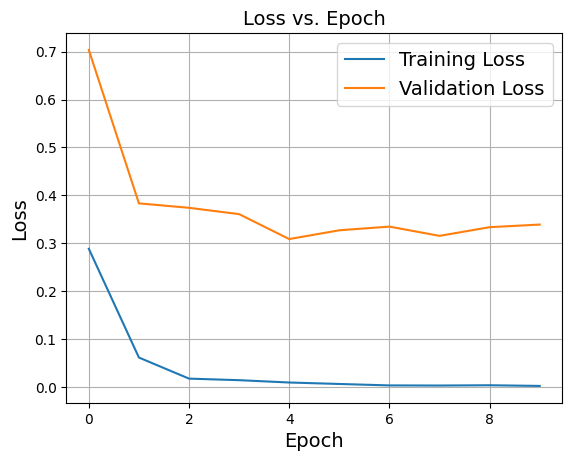

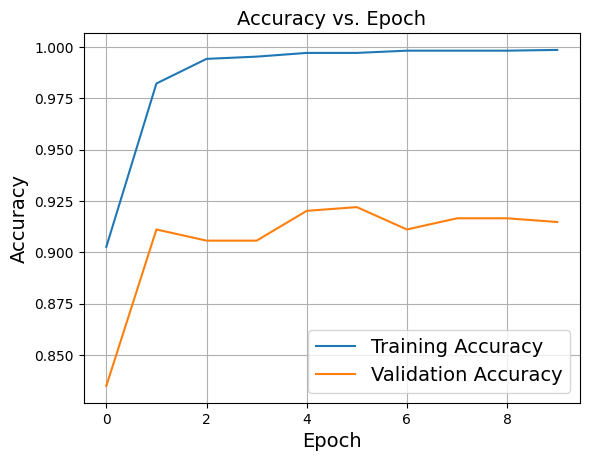

In [57]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Classification and Localization

**Note**: the code below used to reuse the optimizer from the previous model. This was fine in earlier versions of TensorFlow, but in more recent versions it can cause some issues, so a line is added to create a new optimizer here. Also, recent versions of Keras expect one metric per output, so the `"mse"` metric is added to the list.

In [58]:
tf.random.set_seed(42)  # ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
loc_output = tf.keras.layers.Dense(4)(avg)
model = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)  # added this line
model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],  # depends on what you care most about
              optimizer=optimizer, metrics=["accuracy", "mse"])

In [59]:
# fits the model using random target bounding boxes (in real life you would need to create proper targets instead)

def add_random_bounding_boxes(images, labels):
    fake_bboxes = tf.random.uniform([tf.shape(images)[0], 4])
    return images, (labels, fake_bboxes)

fake_train_set = train_set.take(5).repeat(2).map(add_random_bounding_boxes)
model.fit(fake_train_set, epochs=2)

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 526ms/step - dense_1_accuracy: 0.2163 - dense_1_loss: 1.6458 - dense_2_loss: 0.1961 - dense_2_mse: 0.1961 - loss: 1.3559
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 473ms/step - dense_1_accuracy: 0.5851 - dense_1_loss: 1.1877 - dense_2_loss: 0.1605 - dense_2_mse: 0.1605 - loss: 0.9822


# High Accuracy CNN for MNIST

*Exercise: Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST.*

The following model uses 2 convolutional layers, followed by 1 pooling layer, then dropout 25%, then a dense layer, another dropout layer but with 50% dropout, and finally the output layer. It reaches about 99.2% accuracy on the test set. This places this model roughly in the top 20% in the [MNIST Kaggle competition](https://www.kaggle.com/c/digit-recognizer/) (if we ignore the models with an accuracy greater than 99.79% which were most likely trained on the test set, as explained by Chris Deotte in [this post](https://www.kaggle.com/c/digit-recognizer/discussion/61480). If you want to ***do better*** - to reach 99.5 to 99.7% accuracy on the test set - you need to add image augmentation, batch norm, use a learning schedule such as 1-cycle, and possibly create an ensemble.

In [60]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [61]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8933 - loss: 0.3421 - val_accuracy: 0.9892 - val_loss: 0.0421
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9743 - loss: 0.0863 - val_accuracy: 0.9912 - val_loss: 0.0374
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9813 - loss: 0.0596 - val_accuracy: 0.9888 - val_loss: 0.0347
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.9906 - val_loss: 0.0347
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9864 - loss: 0.0424 - val_accuracy: 0.9904 - val_loss: 0.0388
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9896 - loss: 0.0307 - val_accuracy: 0.9908 - val_loss: 0.0364
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9898 - loss: 0.0287 - val_accuracy: 0.9902 - val_loss: 0.0434
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9916 - loss: 0.02

[0.03246799483895302, 0.9921000003814697]